# Assignment and count statistic

Statistic for assignment and counts of the MPRA experiment.

## General code

libraries and scripts

In [3]:
R.version

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          3.3                         
year           2024                        
month          02                          
day            29                          
svn rev        86002                       
language       R                           
version.string R version 4.3.3 (2024-02-29)
nickname       Angel Food Cake             

In [13]:
install.packages("tidyverse")

also installing the dependencies ‘colorspace’, ‘sys’, ‘bit’, ‘ps’, ‘sass’, ‘cachem’, ‘farver’, ‘munsell’, ‘rappdirs’, ‘askpass’, ‘bit64’, ‘processx’, ‘highr’, ‘xfun’, ‘yaml’, ‘bslib’, ‘tinytex’, ‘backports’, ‘memoise’, ‘data.table’, ‘isoband’, ‘scales’, ‘gargle’, ‘cellranger’, ‘curl’, ‘ids’, ‘rematch2’, ‘mime’, ‘openssl’, ‘timechange’, ‘systemfonts’, ‘textshaping’, ‘vroom’, ‘tzdb’, ‘callr’, ‘fs’, ‘knitr’, ‘rmarkdown’, ‘selectr’, ‘stringi’, ‘broom’, ‘conflicted’, ‘dbplyr’, ‘dplyr’, ‘dtplyr’, ‘forcats’, ‘ggplot2’, ‘googledrive’, ‘googlesheets4’, ‘haven’, ‘httr’, ‘lubridate’, ‘magrittr’, ‘modelr’, ‘purrr’, ‘ragg’, ‘readr’, ‘readxl’, ‘reprex’, ‘rvest’, ‘stringr’, ‘tibble’, ‘tidyr’, ‘xml2’


Warning message in install.packages("tidyverse"):
“installation of package ‘colorspace’ had non-zero exit status”
Warning message in install.packages("tidyverse"):
“installation of package ‘sys’ had non-zero exit status”
Warning message in install.packages("tidyverse"):
“installation of package ‘bit’ ha

In [4]:
library(tidyverse)
library(LSD)
# setwd("/fast/groups/ag_kircher/work/MPRA/ProximalPromoter/projects/experiment_statistic")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [5]:
standard_style <- function() {
  ## styles
  size.text = 20;
  size.title = 25;
  size.line = 1;
  size.geom_line = 2;
  size.geom_point = 4
  standard_style <- theme_bw() + theme(plot.title = element_text(size = size.title, face="bold",hjust = 0.5),
                    panel.grid.major = element_blank() , panel.grid.minor = element_blank(), panel.border = element_blank(),
                    axis.text = element_text(colour = "black",size=size.text), axis.title = element_text(colour = "black",size=size.title), axis.ticks = element_line(colour = "black", size=1), axis.line.y = element_line(color="black", size = size.line), axis.line = element_line(colour = "black", size=size.line),
                    legend.key =  element_blank(), legend.text = element_text(size=size.text),
                    legend.direction="horizontal", legend.position = c("top"), legend.background = element_rect(fill = "transparent", colour = "transparent"), legend.margin = margin(0, 0, 0, 0),
                    legend.key.size = unit(2, 'lines'), legend.title=element_text(size=size.text))+
                    theme(axis.line.x = element_line(color="black", size = size.line))
}

## Assignment statistic

In [6]:
result_path <- "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/resequencing_results/"
result_path <- "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/resequencing_results/old_bam_filtering/"
result_path <- "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/resequencing_results/new_bam_filtering/"

In [7]:
input_file = paste0(result_path, "results/assignment/standardAssignIGVFDesignNoTemp/assignment_barcodes.standardConfig.sorted.tsv.gz")
bcs <- read_delim(
    input_file, 
    delim = "\t", escape_double = FALSE, col_names = c("BC", "Oligo", "XS", "Support_ratio"), col_select = c(1,2), trim_ws = TRUE
    )

Rows: 7078311 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): BC, Oligo

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
bcs <- bcs %>%
    group_by(Oligo) %>%
    count() %>% ungroup()

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message in geom_text(aes(y = 800, label = sprintf("\n\nmean = %.2f", mean(bcs$n)), :
“All aesthetics have length 1, but the data has 75131 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message:
“Use of `bcs$n` is discouraged.
ℹ Use `n` instead.”
Warning message in geom_text(aes(y = 800, label = sprintf("\nmedian = %.0f\n", median(bcs$n)), :
“All aesthetics have length 1, but the data has 75131 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Removed 452 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_b

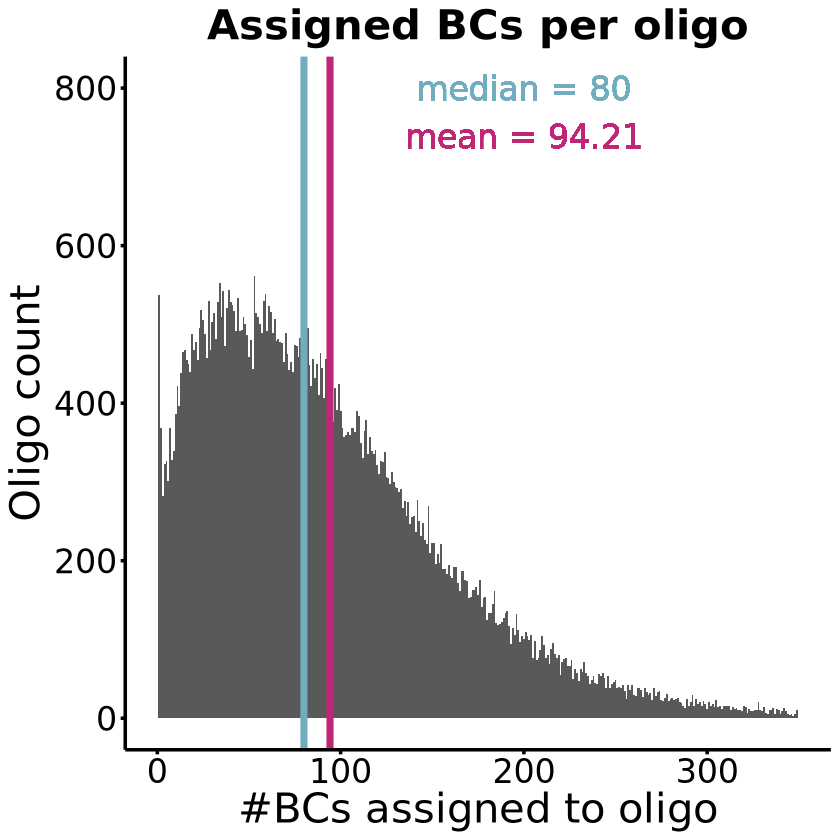

In [9]:
p <- ggplot(bcs, aes(n)) +
    geom_histogram(binwidth = 1) +
    xlim(0,350) +
    geom_vline(aes(xintercept = mean(bcs$n)), col = "#BF2675", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\n\nmean = %.2f", mean(bcs$n)),
        x = 200
    ), colour = "#BF2675",size=7) +
    geom_vline(aes(xintercept = median(bcs$n)), col = "#72ACBF", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\nmedian = %.0f\n", median(bcs$n)),
        x = 200
    ), colour = "#72ACBF",size=7) +
    ylim(0,800) +
    labs(title = "Assigned BCs per oligo", x = "#BCs assigned to oligo", y = "Oligo count") +
    standard_style()

p
#ggsave(opt$plot, p, type="cairo", dpi=300)

In [14]:
# ggsave("plots/assignment_histogram.png", p, type="cairo", dpi=300)
# ggsave("plots/assignment_histogram.pdf", p, dpi=300)
# ggsave("plots/assignment_histogram.svg", p, dpi=300)

## Count statistic

### NGN2

In [10]:
bcs <- read_delim(
    paste0(result_path, "/results/experiments/standard_bwa/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_allreps_merged.tsv.gz"), 
    delim = "\t", escape_double = FALSE, col_select = c("replicate", "name", "dna_counts", "rna_counts", "dna_normalized", "rna_normalized", "log2", "n_obs_bc"), trim_ws = TRUE
    ) %>% filter(name != "no_BC")

Rows: 224893 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): name
dbl (7): replicate, dna_counts, rna_counts, dna_normalized, rna_normalized, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
bcs %>% head()

replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,log2,n_obs_bc
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG,535,1332,0.1211621,0.1172242,0.00508924,128
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA,470,2609,0.1216474,0.2624093,1.16187024,112
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;36:V_HNF3ALPHA_Q6:TGTTTGCTTTG;50:V_HNF6_Q6:CAAAATCAATAA;65:V_HNF4_Q6:AAGGTCCAG;77:V_PPARA_02:CCGGGTCATTGGGGTCAGG;99:V_XBP1_01:GTGATGACGTGTCCCAT;119:V_HNF1_C:AGTTAATGATTAACCAA;139:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,325,833,0.1135084,0.1130551,0.04698273,83
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF3ALPHA_Q6:TGTTTGCTTTG;24:V_HNF6_Q6:CAAAATCAATAA;39:V_Rxra_UP:GGCCGTGACCCCGTGAT;59:V_PPARA_02:CCGGGTCATTGGGGTCAGG;81:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;103:V_HNF1_C:AGTTAATGATTAACCAA;123:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;149:V_HNF4_Q6:AAGGTCCAG,395,1143,0.1080225,0.1214685,0.22200680,106
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF4_Q6:AAGGTCCAG;22:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;44:V_PPARA_02:CCGGGTCATTGGGGTCAGG;66:V_HNF6_Q6:CAAAATCAATAA;81:V_HNF1_C:AGTTAATGATTAACCAA;101:V_HNF3ALPHA_Q6:TGTTTGCTTTG;115:V_XBP1_01:GTGATGACGTGTCCCAT;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,257,678,0.1221311,0.1252054,0.08862287,61
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF6_Q6:CAAAATCAATAA;25:V_PPARA_02:CCGGGTCATTGGGGTCAGG;47:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;69:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;95:V_HNF3ALPHA_Q6:TGTTTGCTTTG;109:V_XBP1_01:GTGATGACGTGTCCCAT;129:V_HNF4_Q6:AAGGTCCAG;141:V_HNF1_C:AGTTAATGATTAACCAA,254,780,0.1389251,0.1657837,0.30775158,53


In [12]:
bcs_per_oligo = bcs %>%
    group_by(name) %>% summarise_at(vars(n_obs_bc), list(name = mean))
bcs_per_oligo %>% head()

name
<dbl>
129.33333
114.00000
87.00000
109.00000
62.33333
51.66667


Warning message in geom_text(aes(y = 800, label = sprintf("\n\nmean = %.2f", mean(name)), :
“All aesthetics have length 1, but the data has 75046 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in geom_text(aes(y = 800, label = sprintf("\nmedian = %.0f\n", median(name)), :
“All aesthetics have length 1, but the data has 75046 rows.
ℹ Did you mean to use `annotate()`?”
Warning message:
“Removed 235 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


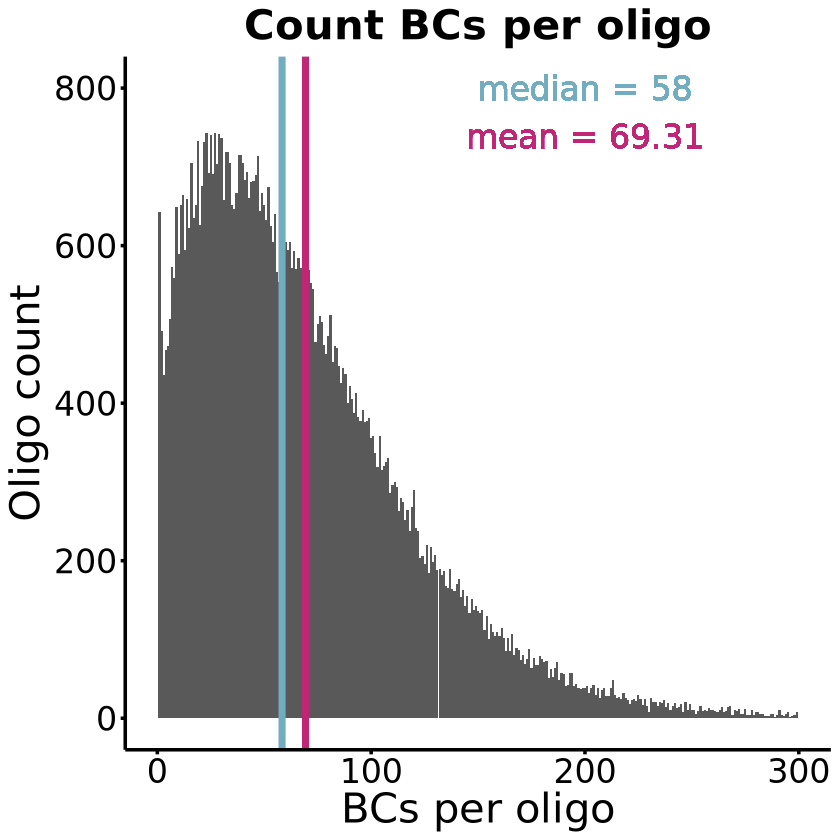

In [13]:
p <- ggplot(bcs_per_oligo, aes(name)) +
    geom_histogram(binwidth = 1) +
    xlim(0,300) +
    geom_vline(aes(xintercept = mean(name)), col = "#BF2675", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\n\nmean = %.2f", mean(name)),
        x = 200
    ), colour = "#BF2675",size=7) +
    geom_vline(aes(xintercept = median(name)), col = "#72ACBF", linewidth = 2) +
    geom_text(aes(
        y = 800, label = sprintf("\nmedian = %.0f\n", median(name)),
        x = 200
    ), colour = "#72ACBF",size=7) +
    ylim(0,800) +
    labs(title = "Count BCs per oligo", x = "BCs per oligo", y = "Oligo count") +
    standard_style()

p

In [19]:
# ggsave("plots/HepG2_count_histogram.png", p, type="cairo", dpi=300)
# ggsave("plots/HepG2_count_histogram.pdf", p, dpi=300)
# ggsave("plots/HepG2_count_histogram.svg", p, dpi=300)

In [36]:
bcs

replicate,name,dna_normalized,rna_normalized,log2,n_obs_bc
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG,0.11750454,0.11606643,0.03553890,112
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA,0.12255282,0.27102150,1.19830822,101
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;36:V_HNF3ALPHA_Q6:TGTTTGCTTTG;50:V_HNF6_Q6:CAAAATCAATAA;65:V_HNF4_Q6:AAGGTCCAG;77:V_PPARA_02:CCGGGTCATTGGGGTCAGG;99:V_XBP1_01:GTGATGACGTGTCCCAT;119:V_HNF1_C:AGTTAATGATTAACCAA;139:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,0.11973265,0.12178915,0.07787359,69
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF3ALPHA_Q6:TGTTTGCTTTG;24:V_HNF6_Q6:CAAAATCAATAA;39:V_Rxra_UP:GGCCGTGACCCCGTGAT;59:V_PPARA_02:CCGGGTCATTGGGGTCAGG;81:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;103:V_HNF1_C:AGTTAATGATTAACCAA;123:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;149:V_HNF4_Q6:AAGGTCCAG,0.10978398,0.12175441,0.20261114,94
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_HNF4_Q6:AAGGTCCAG;22:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;44:V_PPARA_02:CCGGGTCATTGGGGTCAGG;66:V_HNF6_Q6:CAAAATCAATAA;81:V_HNF1_C:AGTTAATGATTAACCAA;101:V_HNF3ALPHA_Q6:TGTTTGCTTTG;115:V_XBP1_01:GTGATGACGTGTCCCAT;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.12385741,0.12800772,0.10085531,55
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_XBP1_01:GTGATGACGTGTCCCAT;30:V_HNF4_Q6:AAGGTCCAG;42:V_HNF6_Q6:CAAAATCAATAA;57:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;79:V_HNF3ALPHA_Q6:TGTTTGCTTTG;93:V_Rxra_UP:GGCCGTGACCCCGTGAT;113:V_PPARA_02:CCGGGTCATTGGGGTCAGG;135:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC,0.09404964,0.10713962,0.24130231,45
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V_XBP1_01:GTGATGACGTGTCCCAT;30:V_HNF4_Q6:AAGGTCCAG;42:V_Rxra_UP:GGCCGTGACCCCGTGAT;62:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC;84:V_HNF3ALPHA_Q6:TGTTTGCTTTG;98:V_PPARA_02:CCGGGTCATTGGGGTCAGG;120:V_COUPTF_Q6:CCCCCTGACCTTTGCCCCCTGCC;146:V_HNF6_Q6:CAAAATCAATAA,0.12305069,0.13931420,0.23239414,49
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|113:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC,0.11305282,0.11687105,0.10122519,40
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|113:V_HNF1_C:AGTTAATGATTAACCAA,0.10785205,0.10221040,-0.02420702,68


[1] "Pearson"
[1] 0.809067
[1] "Spearman"
[1] 0.7524823
[1] "Pearson"
[1] 0.7992901
[1] "Spearman"
[1] 0.7269383


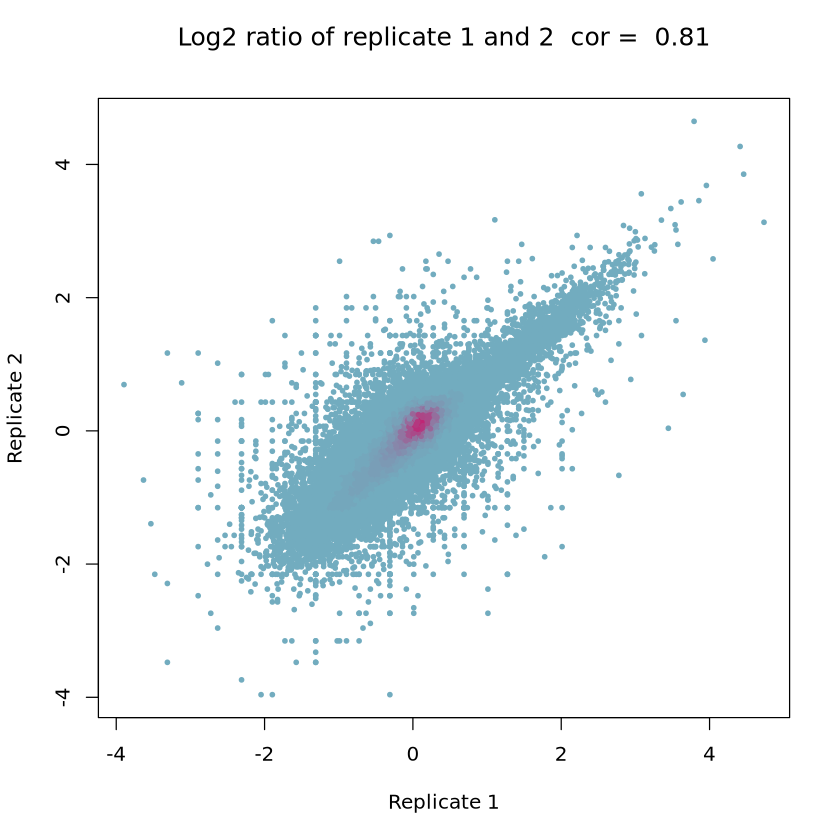

[1] "Pearson"
[1] 0.7758275
[1] "Spearman"
[1] 0.7147488


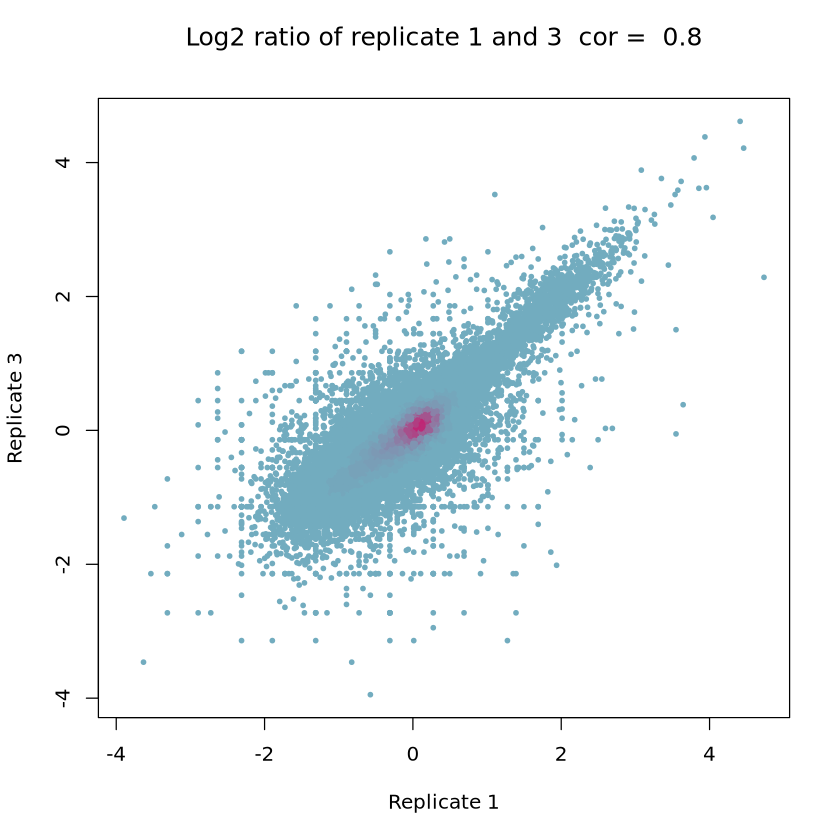

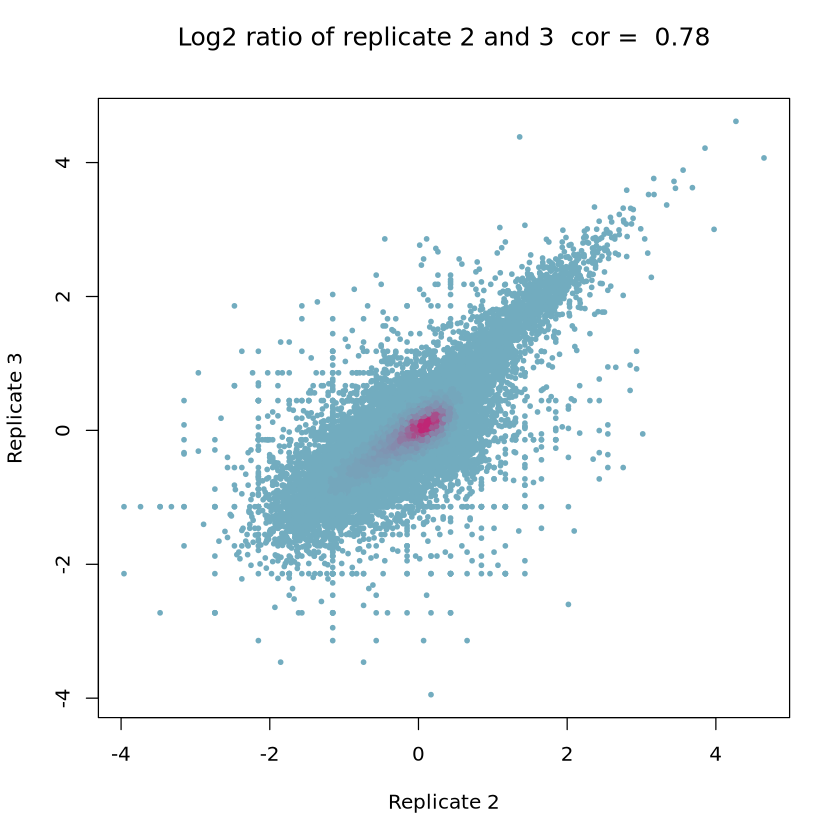

In [37]:
# bcs <- bcs %>% filter(n_obs_bc >= 10)

correlate_replicates <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$log2.x, res$log2.y))
    print("Spearman")
    print(cor(res$log2.x, res$log2.y, method='spearman'))

    p <- heatscatter(res$log2.x, res$log2.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("Log2 ratio of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}

p1 <- correlate_replicates(bcs, 1,2)
p2 <- correlate_replicates(bcs, 1,3)
p3 <- correlate_replicates(bcs, 2,3)



In [22]:
# png("plots/HepG2_count_ratio_correlation.png", width=60, height=20, units="cm", res=300)
# par(mfrow=c(1,3))
# correlate_replicates(bcs, 1,2)
# correlate_replicates(bcs, 1,3)
# correlate_replicates(bcs, 2,3)
# dev.off()

In [23]:
# pdf("plots/HepG2_count_ratio_correlation.pdf", width = 30, height = 10)
# par(mfrow=c(1,3))
# correlate_replicates(bcs, 1,2)
# correlate_replicates(bcs, 1,3)
# correlate_replicates(bcs, 2,3)
# dev.off()


In [24]:
# svg("plots/HepG2_count_ratio_correlation_r1_r2.svg")
# correlate_replicates(bcs, 1,2)
# dev.off()
# svg("plots/HepG2_count_ratio_correlation_r1_r3.svg")
# correlate_replicates(bcs, 1,3)
# dev.off()
# svg("plots/HepG2_count_ratio_correlation_r2_r3.svg")
# correlate_replicates(bcs, 2,3)
# dev.off()

### DNA and RNA correlation

#### Normalized

[1] "Pearson"
[1] 0.7378126
[1] "Spearman"
[1] 0.7819736
[1] "Pearson"
[1] 0.776742
[1] "Spearman"
[1] 0.8144843


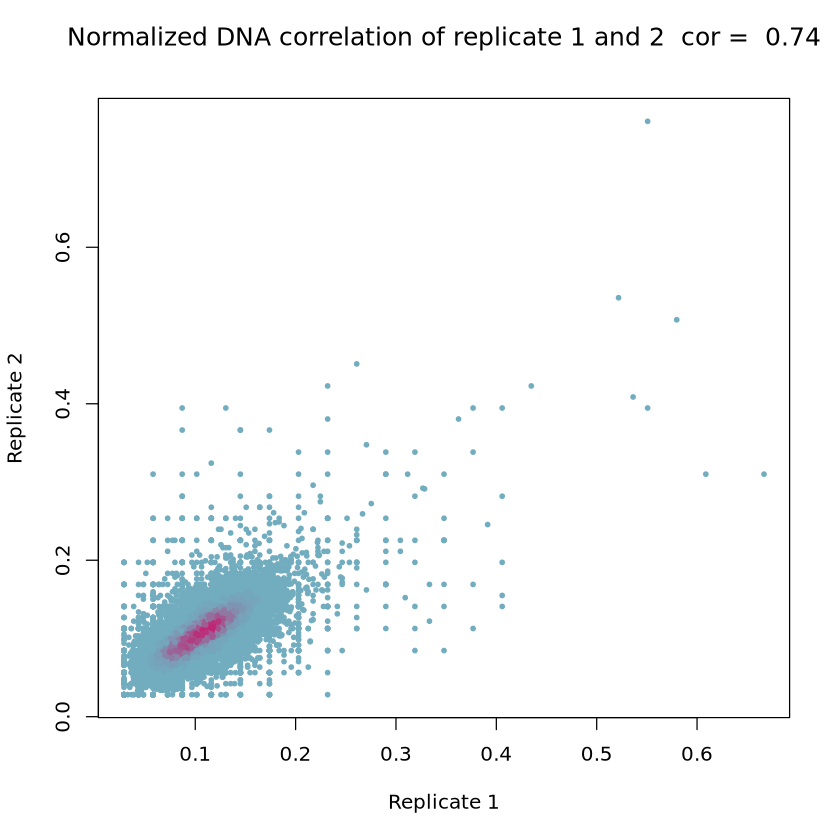

[1] "Pearson"
[1] 0.748512
[1] "Spearman"
[1] 0.7952556


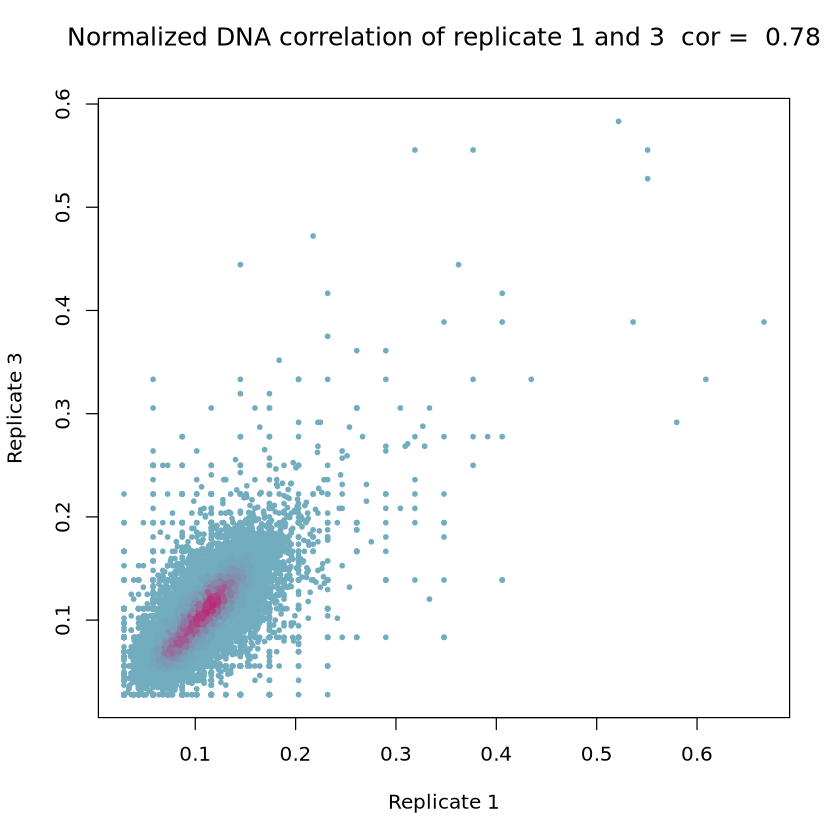

[1] "Pearson"
[1] 0.8199697
[1] "Spearman"
[1] 0.8245177


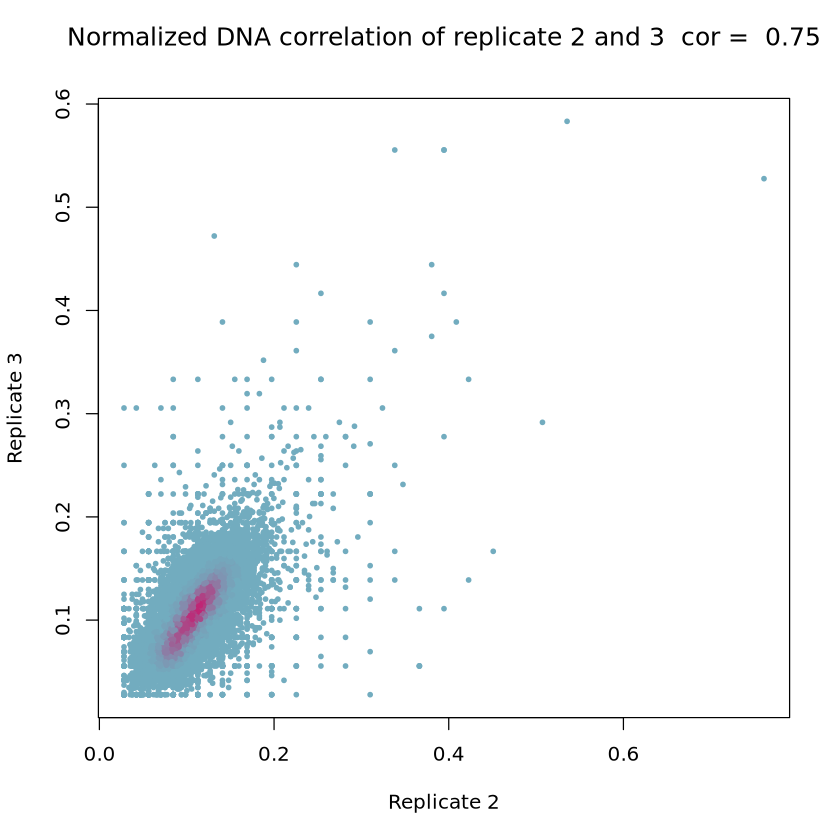

[1] "Pearson"
[1] 0.8520324
[1] "Spearman"
[1] 0.8560078


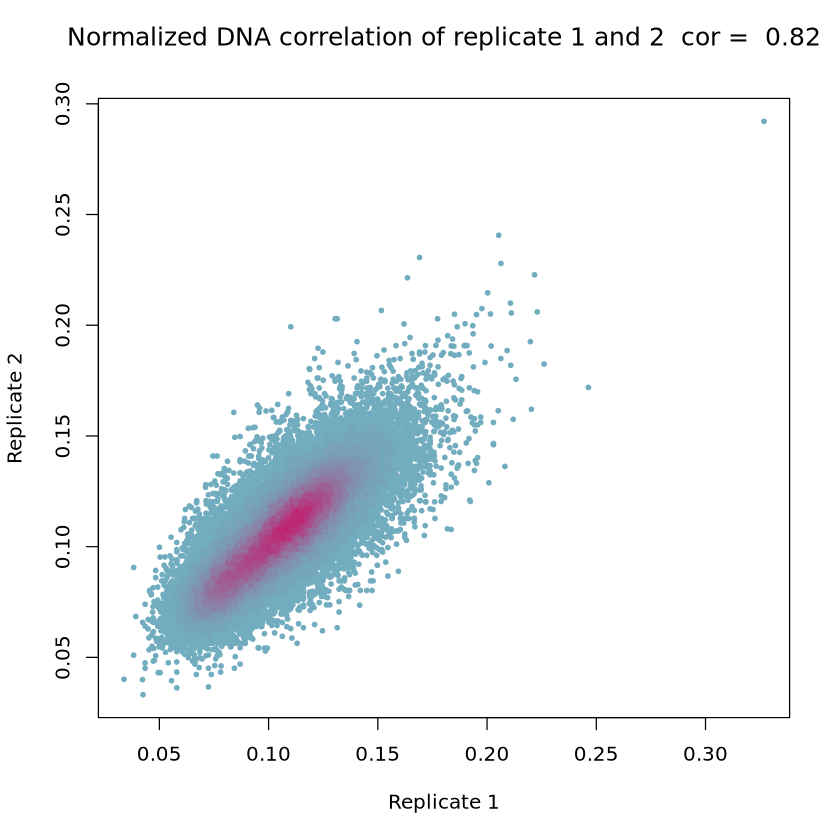

[1] "Pearson"
[1] 0.8324042
[1] "Spearman"
[1] 0.8373236


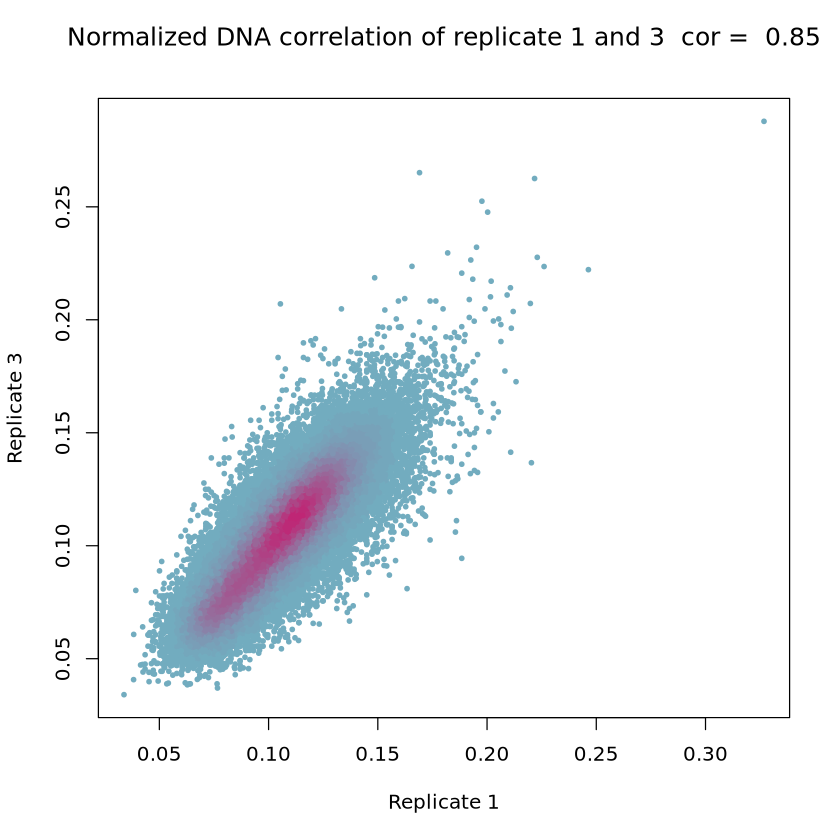

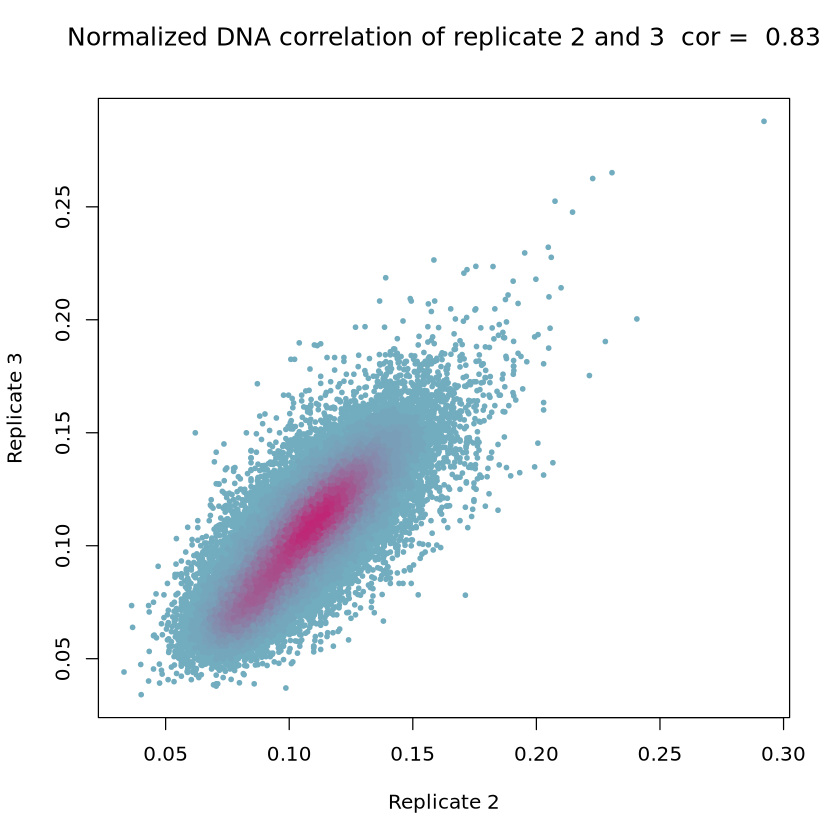

In [42]:
# DNA normalized with filtered
bcs_filtered <- bcs %>% filter(n_obs_bc >= 10)

correlate_replicates_dna_normalized <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$dna_normalized.x, res$dna_normalized.y))
    print("Spearman")
    print(cor(res$dna_normalized.x, res$dna_normalized.y, method='spearman'))

    p <- heatscatter(res$dna_normalized.x, res$dna_normalized.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("Normalized DNA correlation of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}



p1 <- correlate_replicates_dna_normalized(bcs, 1,2)
p2 <- correlate_replicates_dna_normalized(bcs, 1,3)
p3 <- correlate_replicates_dna_normalized(bcs, 2,3)
p1 <- correlate_replicates_dna_normalized(bcs_filtered, 1,2)
p2 <- correlate_replicates_dna_normalized(bcs_filtered, 1,3)
p3 <- correlate_replicates_dna_normalized(bcs_filtered, 2,3)



RNA Normalized

[1] "Pearson"
[1] 0.953404
[1] "Spearman"
[1] 0.9489062
[1] "Pearson"
[1] 0.9728775
[1] "Spearman"
[1] 0.9527471


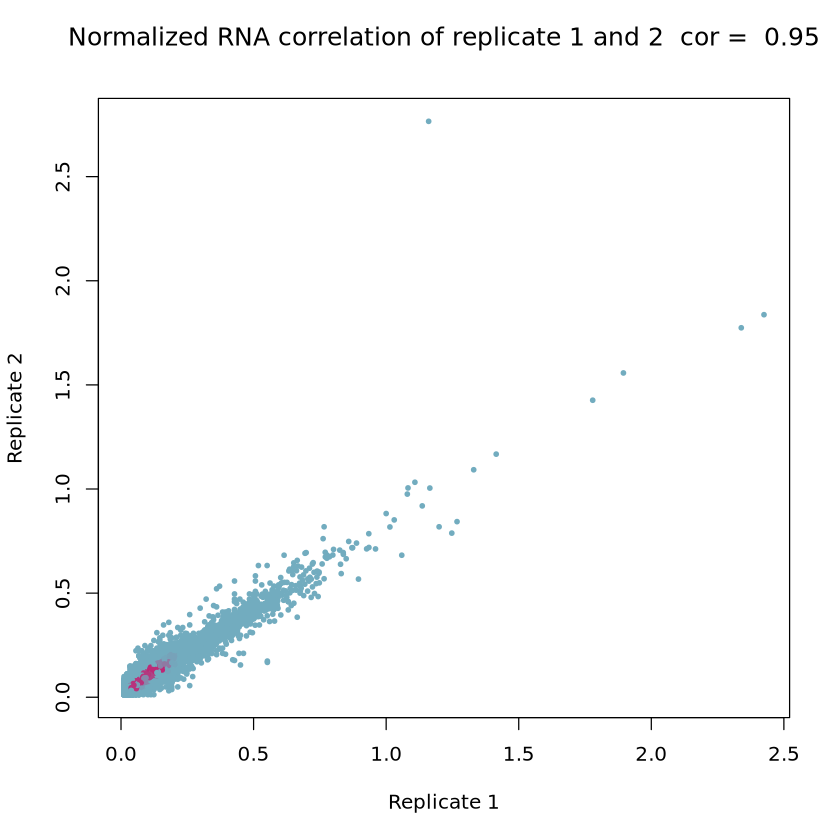

[1] "Pearson"
[1] 0.9491877
[1] "Spearman"
[1] 0.9459888


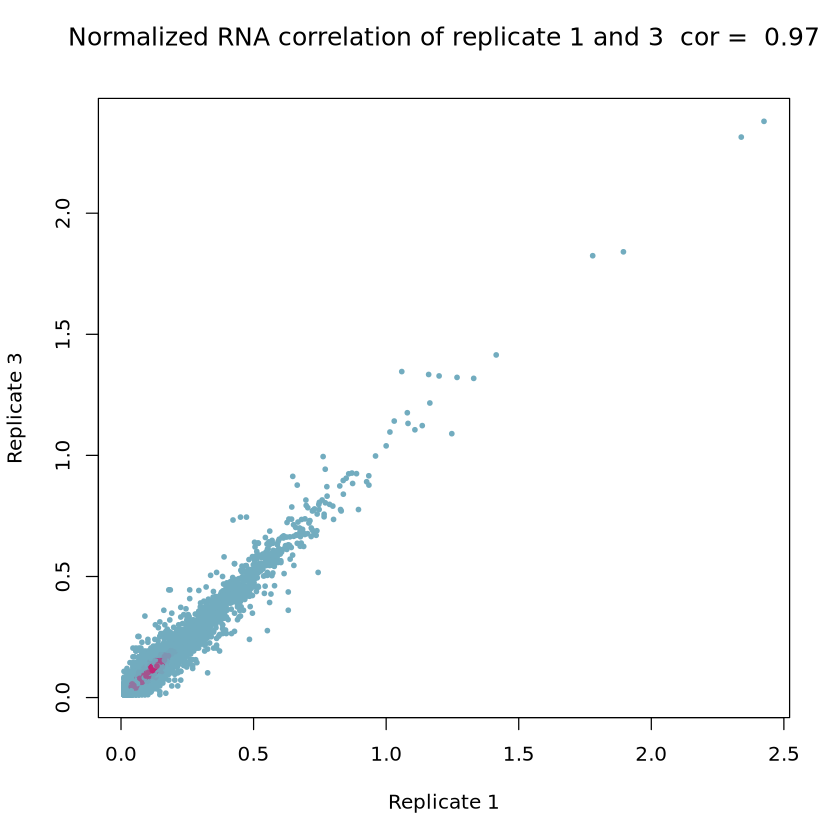

[1] "Pearson"
[1] 0.973517
[1] "Spearman"
[1] 0.962706


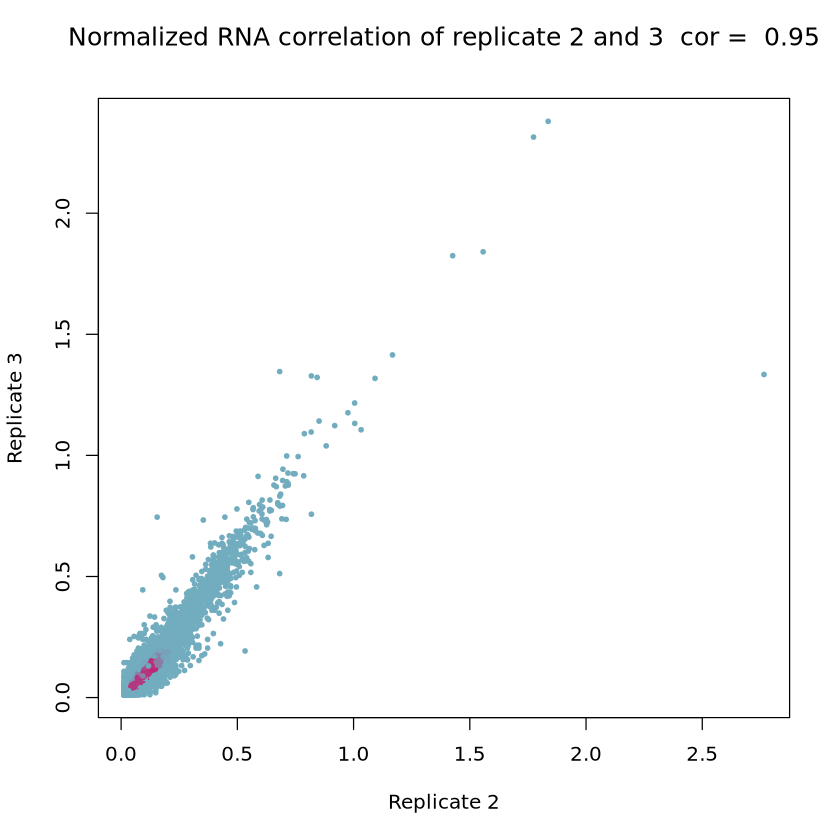

[1] "Pearson"
[1] 0.9843396
[1] "Spearman"
[1] 0.9652042


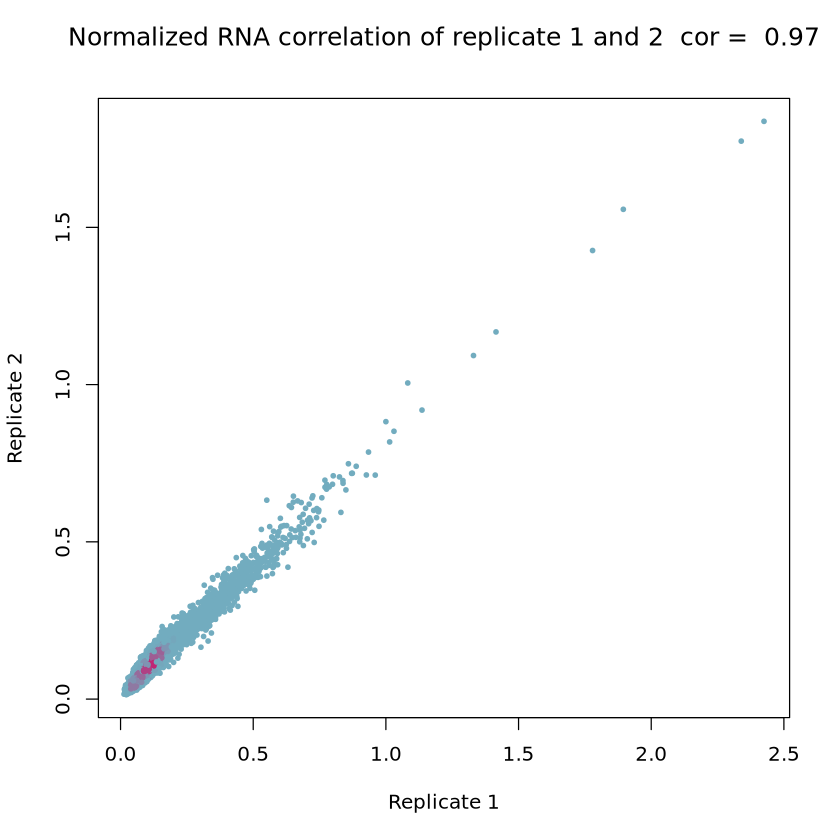

[1] "Pearson"
[1] 0.9691731
[1] "Spearman"
[1] 0.9601152


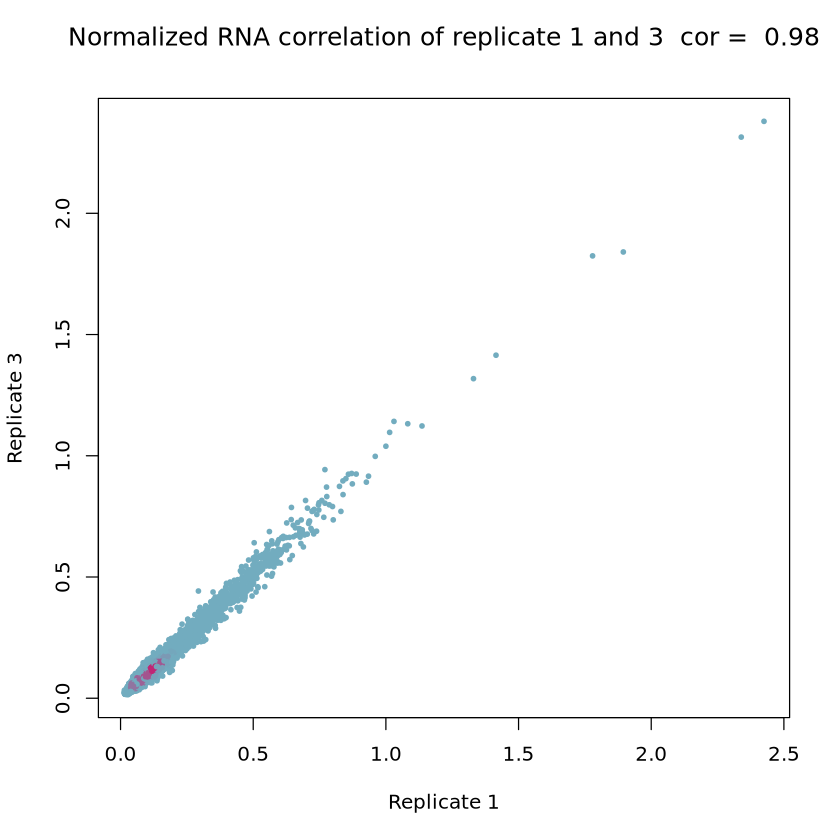

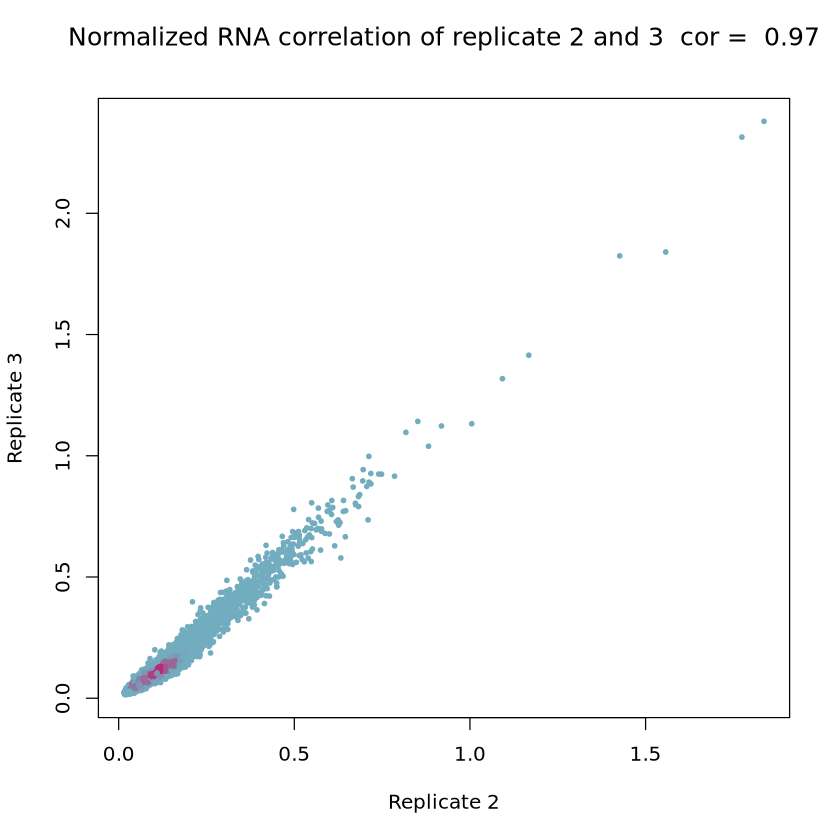

In [43]:

correlate_replicates_rna_normalized <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$rna_normalized.x, res$rna_normalized.y))
    print("Spearman")
    print(cor(res$rna_normalized.x, res$rna_normalized.y, method='spearman'))

    p <- heatscatter(res$rna_normalized.x, res$rna_normalized.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("Normalized RNA correlation of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}


p1 <- correlate_replicates_rna_normalized(bcs, 1,2)
p2 <- correlate_replicates_rna_normalized(bcs, 1,3)
p3 <- correlate_replicates_rna_normalized(bcs, 2,3)
p1 <- correlate_replicates_rna_normalized(bcs_filtered, 1,2)
p2 <- correlate_replicates_rna_normalized(bcs_filtered, 1,3)
p3 <- correlate_replicates_rna_normalized(bcs_filtered, 2,3)

#### Normal counts

[1] "Pearson"
[1] 0.9925735
[1] "Spearman"
[1] 0.9913634
[1] "Pearson"
[1] 0.9928446
[1] "Spearman"
[1] 0.9912672


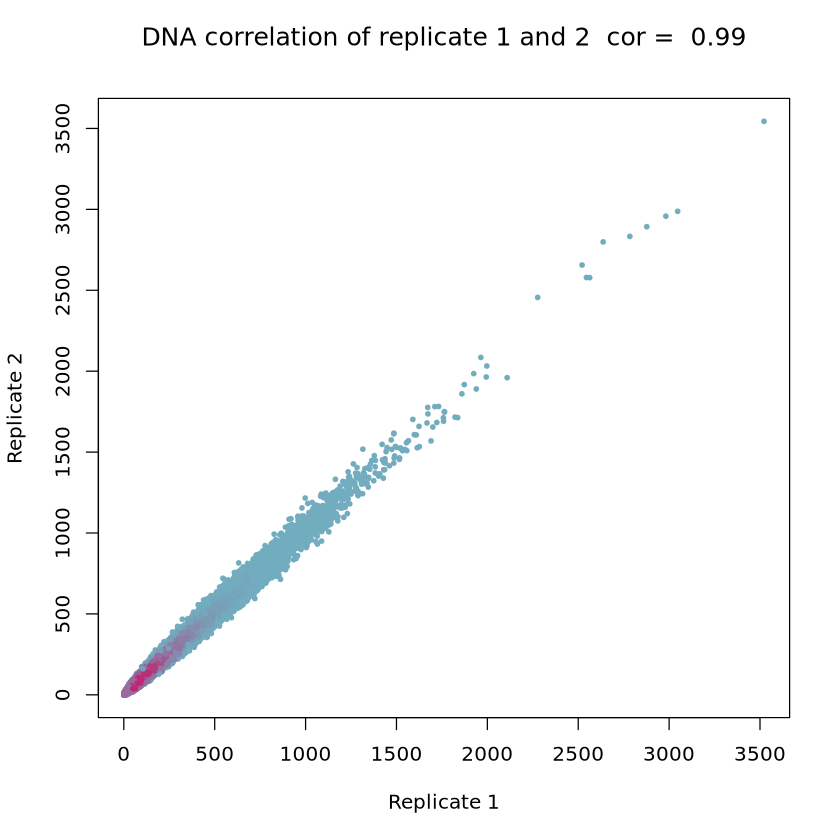

[1] "Pearson"
[1] 0.9911026
[1] "Spearman"
[1] 0.9893429


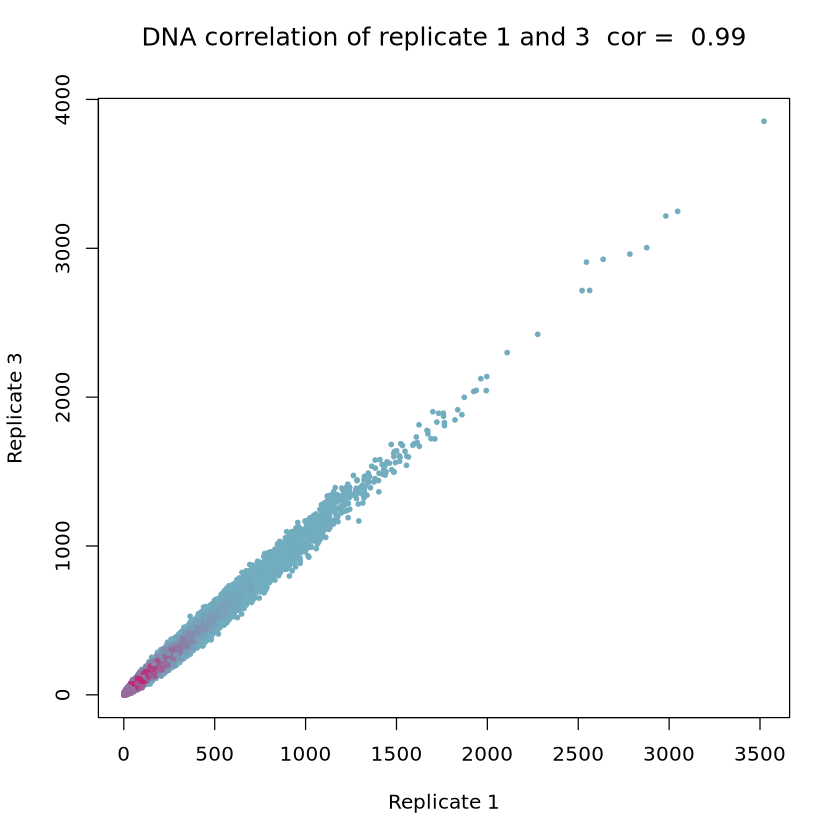

[1] "Pearson"
[1] 0.9916758
[1] "Spearman"
[1] 0.9889713


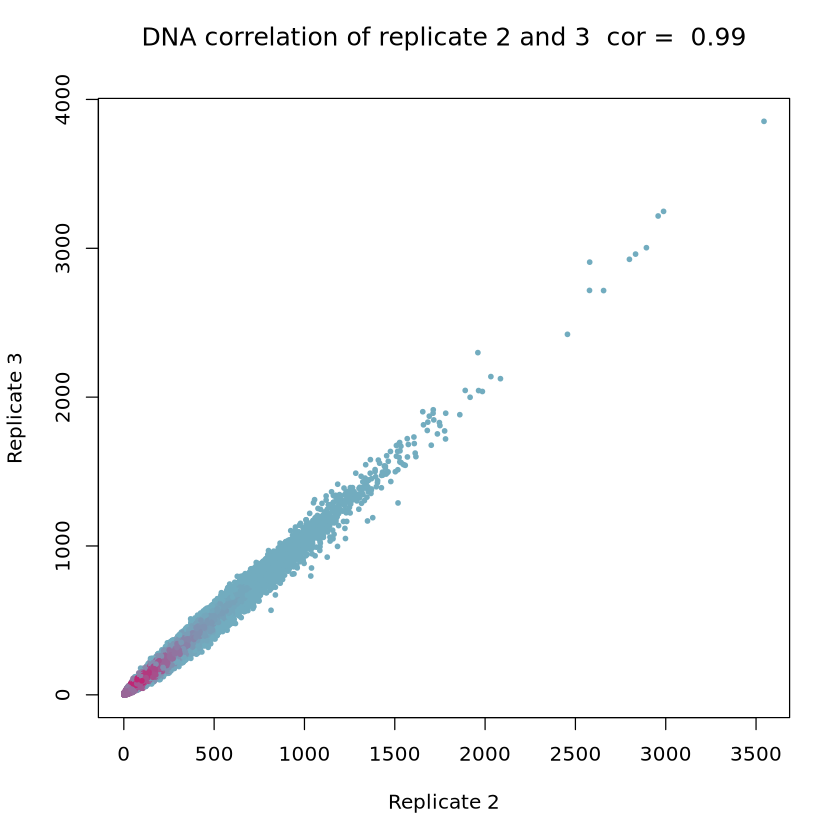

[1] "Pearson"
[1] 0.9920301
[1] "Spearman"
[1] 0.9888756


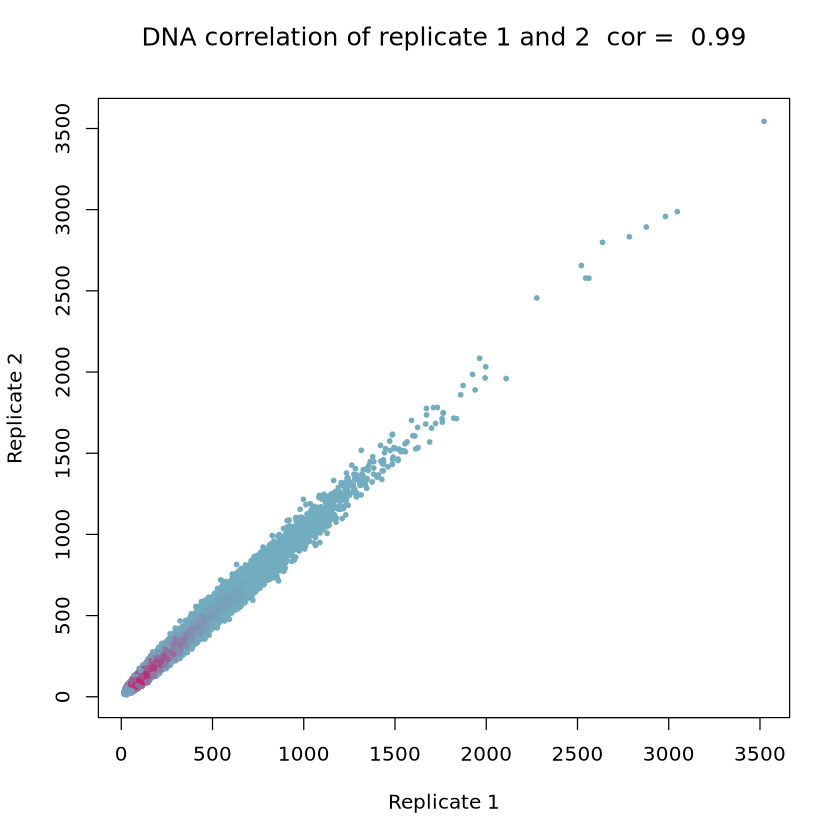

[1] "Pearson"
[1] 0.9900945
[1] "Spearman"
[1] 0.9863742


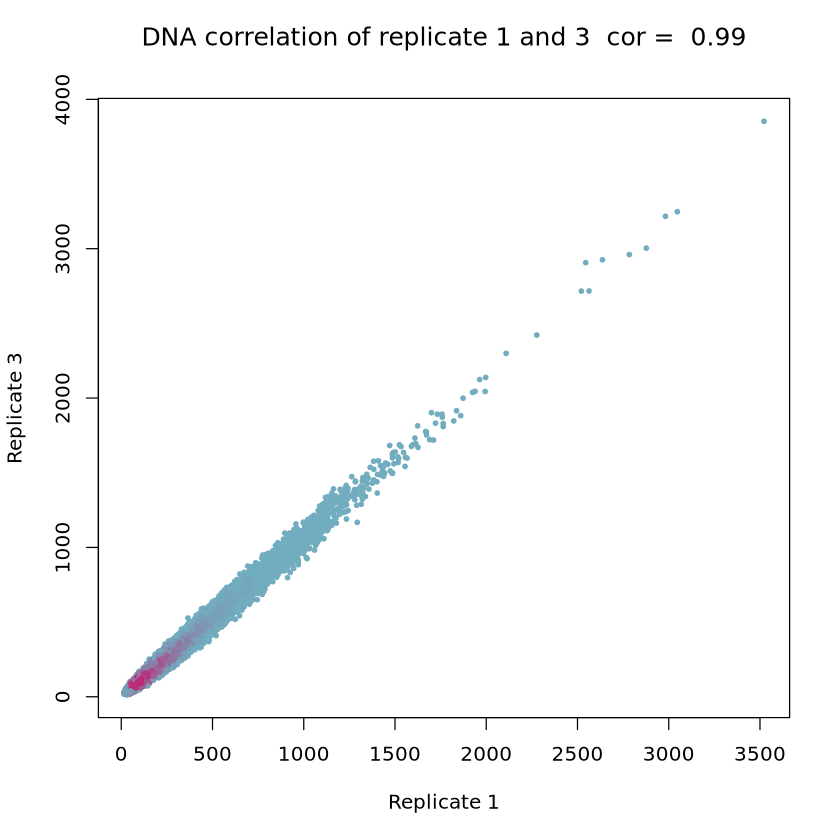

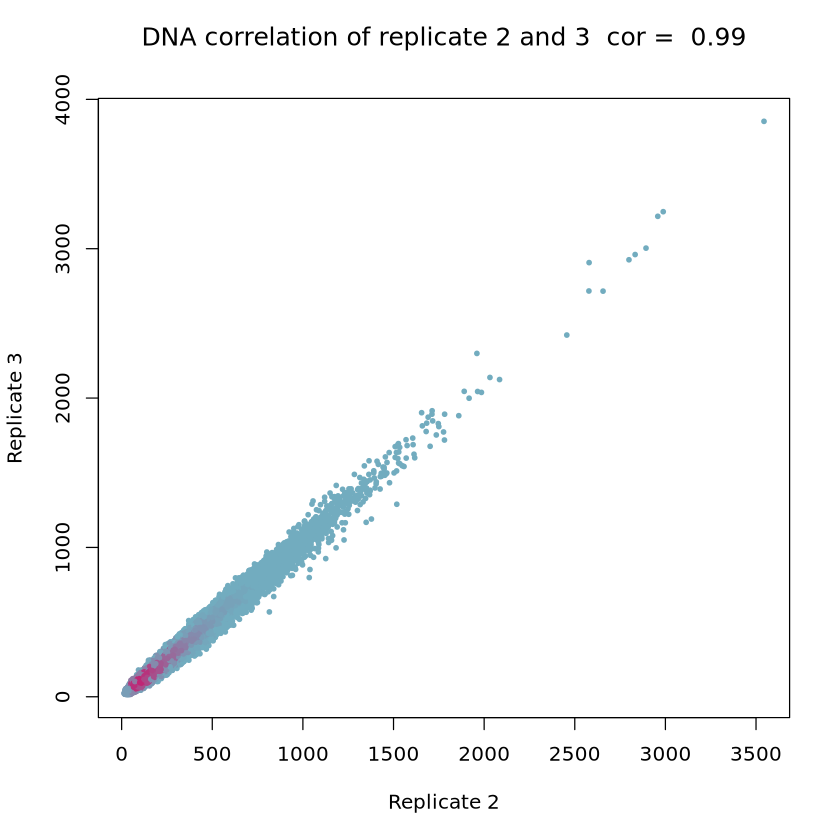

In [46]:
correlate_replicates_dna <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$dna_counts.x, res$dna_counts.y))
    print("Spearman")
    print(cor(res$dna_counts.x, res$dna_counts.y, method='spearman'))

    p <- heatscatter(res$dna_counts.x, res$dna_counts.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("DNA correlation of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}



p1 <- correlate_replicates_dna(bcs, 1,2)
p2 <- correlate_replicates_dna(bcs, 1,3)
p3 <- correlate_replicates_dna(bcs, 2,3)
p1 <- correlate_replicates_dna(bcs_filtered, 1,2)
p2 <- correlate_replicates_dna(bcs_filtered, 1,3)
p3 <- correlate_replicates_dna(bcs_filtered, 2,3)

RNA counts

[1] "Pearson"
[1] 0.9933539
[1] "Spearman"
[1] 0.9955529
[1] "Pearson"
[1] 0.9972851
[1] "Spearman"
[1] 0.9961179


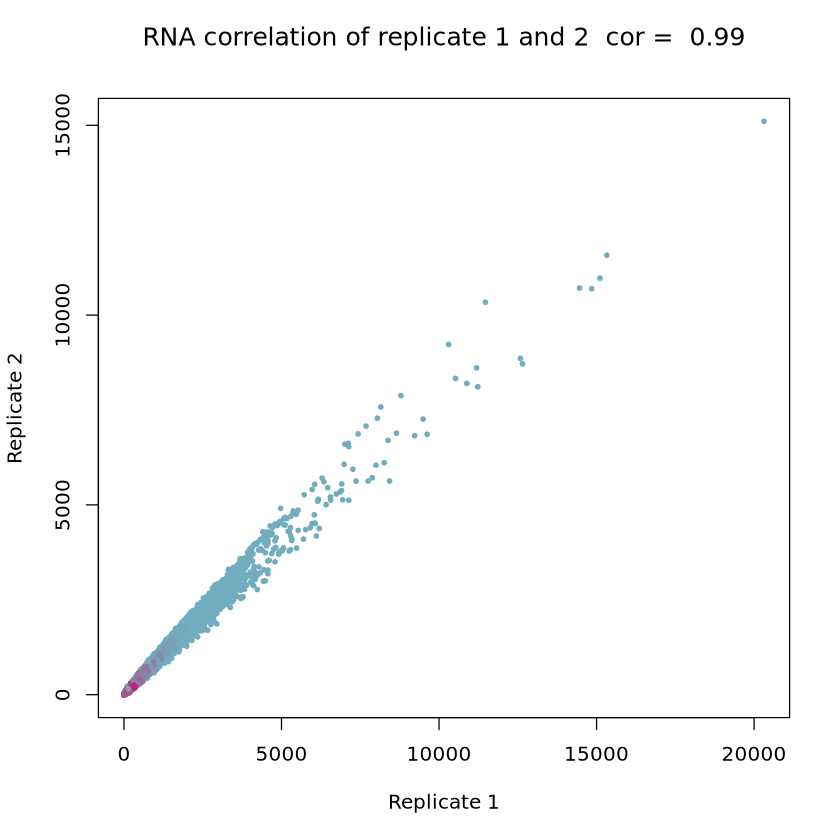

[1] "Pearson"
[1] 0.9917802
[1] "Spearman"
[1] 0.9952135


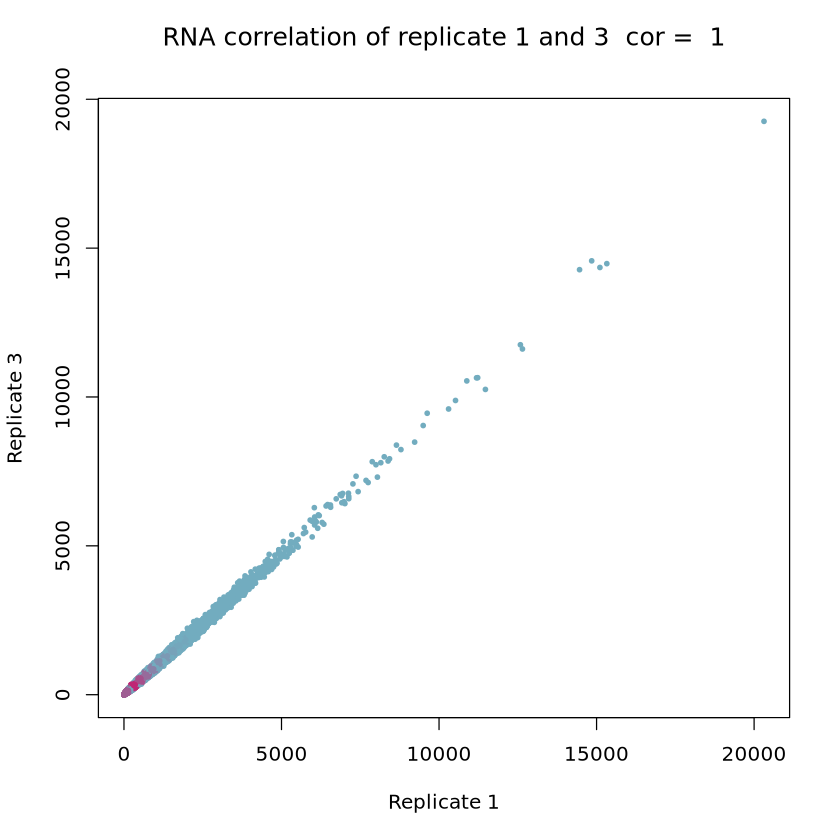

[1] "Pearson"
[1] 0.9928377
[1] "Spearman"
[1] 0.9945898


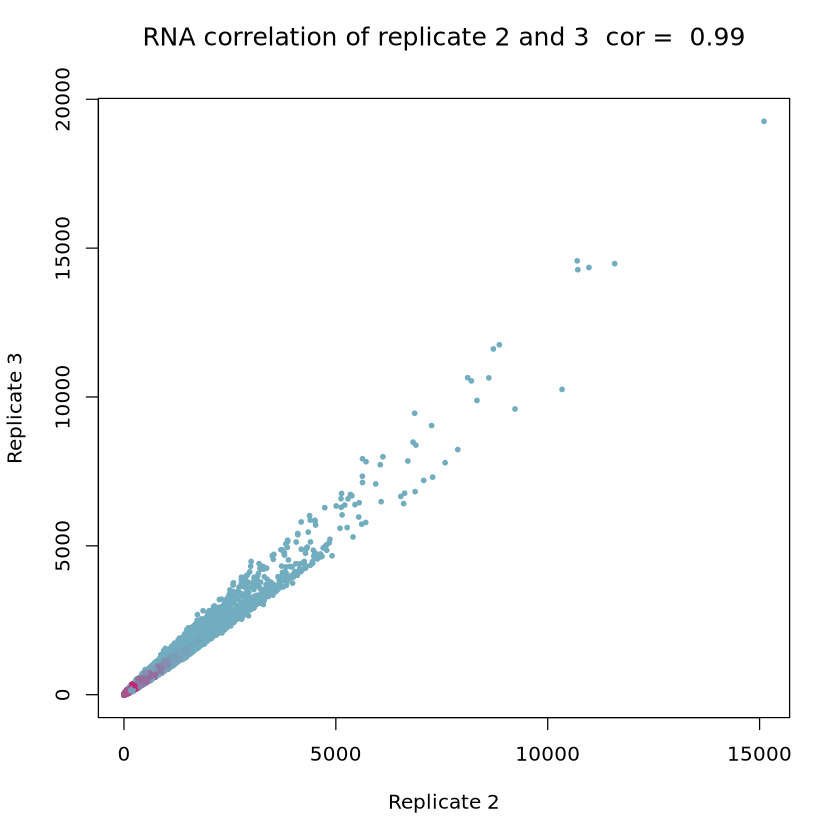

[1] "Pearson"
[1] 0.9970748
[1] "Spearman"
[1] 0.9952791


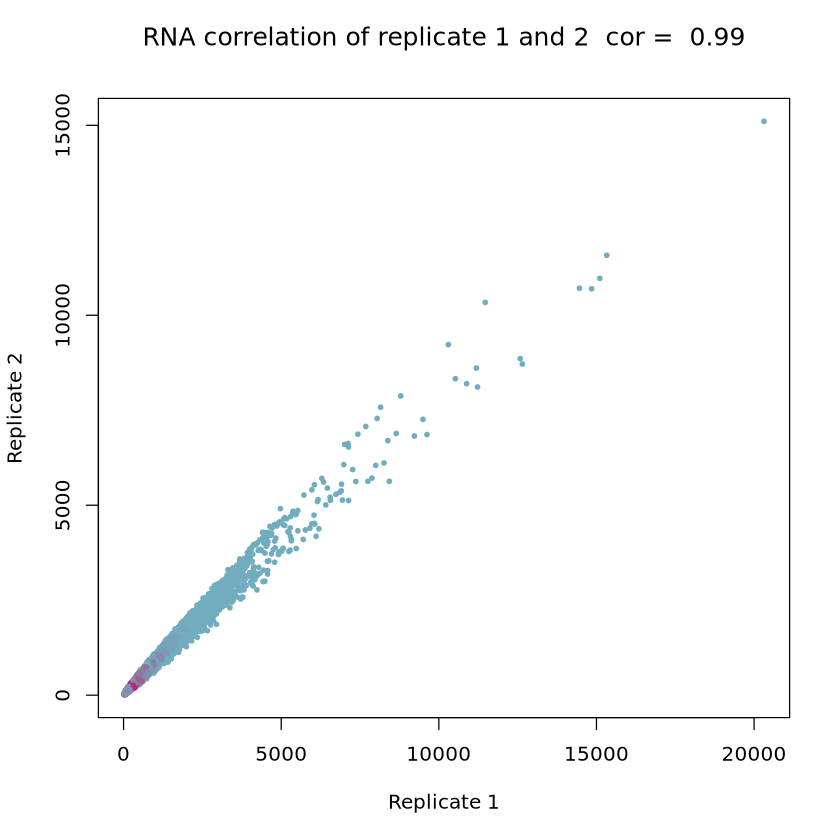

[1] "Pearson"
[1] 0.9911459
[1] "Spearman"
[1] 0.9941768


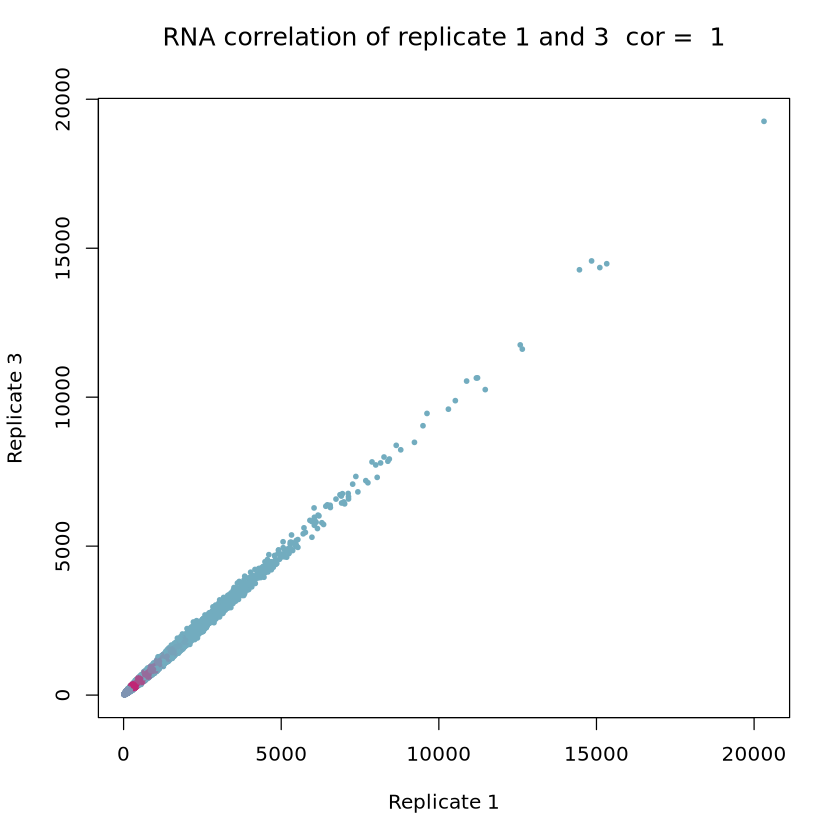

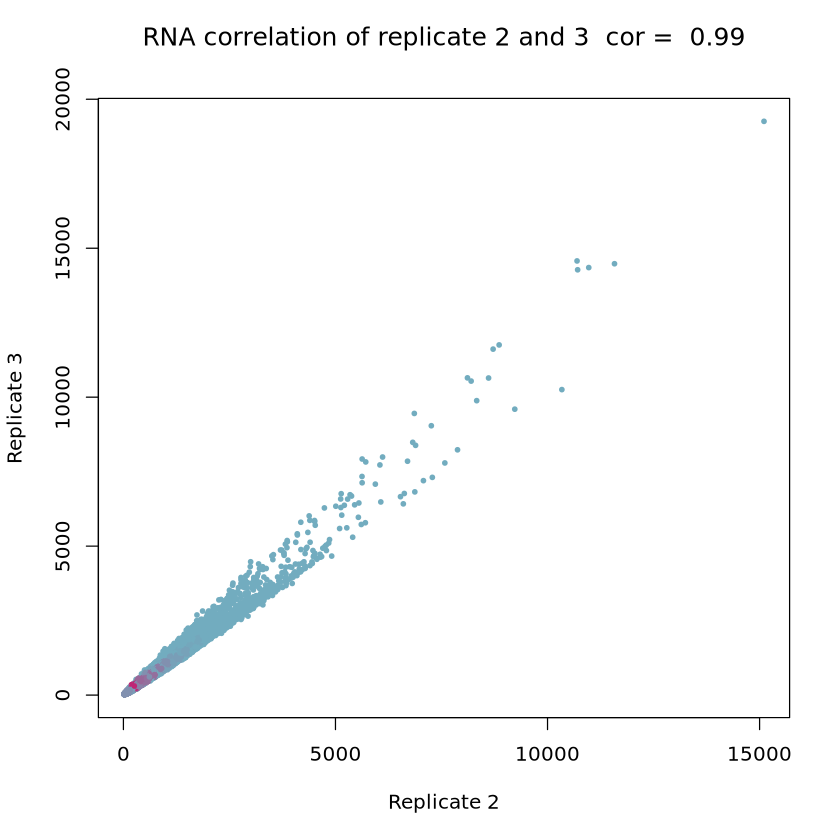

In [45]:
correlate_replicates_rna <- function(data, r1, r2) {
    data1 = data %>% filter(replicate == r1)
    data2 = data %>% filter(replicate == r2)
    res <- data1 %>% inner_join(data2, by = c("name"))

    print("Pearson")
    print(cor(res$rna_counts.x, res$rna_counts.y))
    print("Spearman")
    print(cor(res$rna_counts.x, res$rna_counts.y, method='spearman'))

    p <- heatscatter(res$rna_counts.x, res$rna_counts.y, 
        xlab=sprintf("Replicate %d", r1), 
        ylab=sprintf("Replicate %d", r2),
        cex=0.5,
        cor=TRUE,
        method="pearson",
        main=sprintf("RNA correlation of replicate %d and %d", r1, r2),
        colpal=c( "#72ACBF", "#BF2675")
    )
    return(p)
}



p1 <- correlate_replicates_rna(bcs, 1,2)
p2 <- correlate_replicates_rna(bcs, 1,3)
p3 <- correlate_replicates_rna(bcs, 2,3)
p1 <- correlate_replicates_rna(bcs_filtered, 1,2)
p2 <- correlate_replicates_rna(bcs_filtered, 1,3)
p3 <- correlate_replicates_rna(bcs_filtered, 2,3)